In [62]:
import pandas as pd 

df = pd.read_csv('../data/ai4i2020.csv')

df.head(20)
#print(df.columns)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [63]:
df = df.drop(columns=['Product ID','UDI'])

#umbennenen der Typewerte
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Type'] = encoder.fit_transform(df['Type'])

# Features (Eingabedaten)
X = df.drop(['Machine failure','TWF', 'HDF', 'PWF', 'OSF','RNF'], axis=1)

# Zielvariablen 
y_target = df['Machine failure'] 
y_failure = df[['TWF', 'HDF', 'PWF', 'OSF','RNF']] # Fehlerart

**RandomForest** <br> 
Erstellt viele Entscheidungsbäume <br>
Am Ende wird geschaut, welches Ereignis am wahrscheinlichsetn ist <br>
Klassifikaor baut viele Entscheidungsbäume auf, die lernen, wie man aus Eingabedaten das richitge Ergebnis vorhersagt 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.84      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.91      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



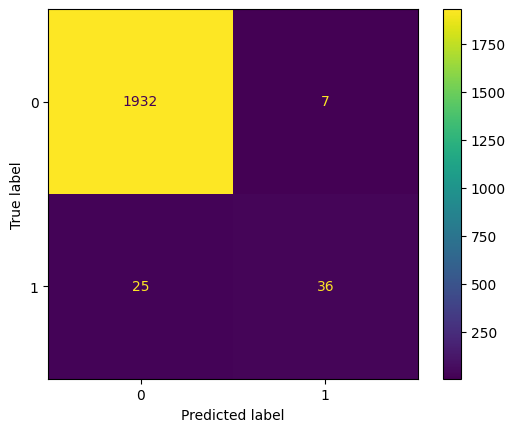

In [64]:
# Binarer Klassifizierer 
# Unterscheidet nur zwischen Ausfall und nicht Ausfall -> 1, 0
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# aufteilen der Daten in Trainings und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)

# einen Klassifizierer erstellen 
# mit den Trainingsdaten trainieren ->.fit
rf_target = RandomForestClassifier(random_state=42)
rf_target.fit(X_train, y_train)

# mit unbekannten Testdaten rüfen, ob die trainierten Muster richtig erkannt werden 
y_pred = rf_target.predict(X_test)

print(classification_report(y_test,y_pred))
ConfusionMatrixDisplay.from_estimator(rf_target, X_test, y_test)
plt.show()


precision -> Von allen als Fehler erkannten Fällen, wie viele waren wirklich Fehler <br>
recall -> Von allen tatsächlichen Fehlern, wie viele waren wirklich fehler <br>
f1-score -> Kobination aus precision und recall <br>
accuracy -> wie viele vorhersagen waren insgesamt richtig <br>

Man sieht, dass das Modell sehr genau ist -> 98% accuracy, allerdings <br>
erkennt das Modell Fehler nicht so gut -> recall 59% -> von allen tatsächlichen Fehlern erkennt er nur 59 richtig. 

**Multilabel-Klassifikator** <br>
Wir haben verschiedene Fehlerarten.

In [65]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split( X, y_failure, test_size=0.2, random_state=42)

multi_rf = MultiOutputClassifier(RandomForestClassifier(random_state=42))
multi_rf.fit(X_train, y_train)

y_pred = multi_rf.predict(X_test)

In [66]:
from sklearn.metrics import classification_report

for i, col in enumerate(y_failure.columns):
    print(f"\n=== Fehlerart: {col} ===")
    print(classification_report(y_test[col], y_pred[:, i]))


=== Fehlerart: TWF ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1989
           1       0.00      0.00      0.00        11

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000


=== Fehlerart: HDF ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1983
           1       1.00      0.76      0.87        17

    accuracy                           1.00      2000
   macro avg       1.00      0.88      0.93      2000
weighted avg       1.00      1.00      1.00      2000


=== Fehlerart: PWF ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1980
           1       0.94      0.75      0.83        20

    accuracy                           1.00      2000
   macro avg       0.97      0.87      0.92      2000
we

/Users/sandrasommerkorn/Downloads/Predictive-Maintenance-Systems-main/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sandrasommerkorn/Downloads/Predictive-Maintenance-Systems-main/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sandrasommerkorn/Downloads/Predictive-Maintenance-Systems-main/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi

Das Modell sollte vorhersagten, welcher Fehler vorliegt, aber anhand des recalls lässt sich erkennen, das das Modell sehr schlecht ist. <br>
Die Fehlerart TWF erkennt das modell nie, obwohl es 11 Fehler gab. Das liegt daran, das die Klassen sehr unausgeglichen sind. Es gibt nur 11 Fehler in 2000 Daten. Es ist schwierig für das Modell Fehler richtig zu erkennen. <br>
Die Fehlerart HDF kann das Modell schon besser erkennen. In 76% der Fälle erkennt er den echten Fehler hat das Modell richtig erkannt. Die Precision von 1 sagt aus, das das Modell wenn es einen Fehler erkennt immer richtig liegt. Also von allen als Fehler identifizierten Fälle, sind alle auch wirklich Fehler.<br>
**Problem beim Modell**
Es erkennt seltene Fehler nicht zuverlässig. Class Imbalance 

Ich habe versucht mit class_weight = balanced das Problem zu verbesser, zu lösen. Es soll wohl die Wenigen daten wichitger machen und die andern unwichtiger, aber so gut passt das nicht. 

In [68]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split( X, y_failure, test_size=0.2, random_state=42)

multi_rf_cw = MultiOutputClassifier(RandomForestClassifier(class_weight="balanced",random_state=42))
multi_rf_cw.fit(X_train, y_train)

y_pred = multi_rf_cw.predict(X_test)

from sklearn.metrics import classification_report

for i, col in enumerate(y_failure.columns):
    print(f"\n=== Fehlerart: {col} ===")
    print(classification_report(y_test[col], y_pred[:, i]))


=== Fehlerart: TWF ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1989
           1       1.00      0.09      0.17        11

    accuracy                           0.99      2000
   macro avg       1.00      0.55      0.58      2000
weighted avg       1.00      0.99      0.99      2000


=== Fehlerart: HDF ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1983
           1       0.92      0.65      0.76        17

    accuracy                           1.00      2000
   macro avg       0.96      0.82      0.88      2000
weighted avg       1.00      1.00      1.00      2000


=== Fehlerart: PWF ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1980
           1       0.78      0.70      0.74        20

    accuracy                           0.99      2000
   macro avg       0.89      0.85      0.87      2000
we

/Users/sandrasommerkorn/Downloads/Predictive-Maintenance-Systems-main/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sandrasommerkorn/Downloads/Predictive-Maintenance-Systems-main/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sandrasommerkorn/Downloads/Predictive-Maintenance-Systems-main/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi